# Create Time Series of Electricity Demand


In [1]:
# Start by importing the packages we need:
import os
import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import timedelta


## Set the Directory Structure

In [2]:
# Identify the data input and output directories:
metadata_input_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/data/'
integrated_time_series_data_input_dir = '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/data/integrated_time_series/'
image_output_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/figures/regional_results/'


## Make the Plot


In [3]:
def plot_load_time_series(region: str, start_date: str, end_date: str, 
                          metadata_input_dir: str, integrated_time_series_data_input_dir: str, image_output_dir: str, image_resolution: int, save_images=False):

    # Read in NERC region name file and extract the name:
    nerc = pd.read_csv((metadata_input_dir + 'nerc_tpl08_region_names.csv'))
    nerc_name = nerc.loc[nerc['short_name'] == region, 'long_name'].item()
    
    # Read in the heat wave event library:
    region_df = pd.read_csv((integrated_time_series_data_input_dir + region + '_Integrated_Time_Series_1982_to_2019.csv'))

    # Calculate the implied total demand at the time of peak load:
    region_df['Inferred_Demand'] = region_df['Coal'] + region_df['Gas'] + region_df['Hydro'] + region_df['Other'] + region_df['Solar'] + region_df['Wind'] + region_df['Imports'] + region_df['Load_Shed']
    
    # Subset the data to just dates within the time window:
    region_df['Time_UTC'] = pd.to_datetime(region_df['Time_UTC'])
    region_df = region_df[(region_df['Time_UTC'] >= pd.to_datetime(start_date)) & (region_df['Time_UTC'] <= pd.to_datetime(end_date))].copy()

    # Calculate the minimum and maximum load values to use in plotting:
    load_min = min([region_df['Region_Load'].min(), region_df['Inferred_Demand'].min()])*0.98
    load_max = max([region_df['Region_Load'].max(), region_df['Inferred_Demand'].max()])*0.98
    
    # Make the plot:
    plt.figure(figsize=(20,20))
    plt.rcParams['font.size'] = 18
    plt.rcParams['axes.axisbelow'] = True
    
    plt.subplot(211)
    plt.plot(region_df['Time_UTC'], region_df['Region_Load'], color='k', linestyle='-', linewidth=1)
    plt.xlim([pd.to_datetime(start_date), pd.to_datetime(end_date)])
    plt.ylim(load_min, load_max)
    plt.ylabel('Demand [MW]')
    plt.title(('Hourly TELL Demand in ' + nerc_name))

    plt.subplot(212)
    plt.plot(region_df['Time_UTC'], region_df['Inferred_Demand'], color='k', linestyle='-', linewidth=1)
    plt.xlim([pd.to_datetime(start_date), pd.to_datetime(end_date)])
    plt.ylim(load_min, load_max)
    plt.ylabel('Demand [MW]')
    plt.title(('Hourly Inferred Demand (Generation + Imports + Load Shedding) in ' + nerc_name))
    
    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       filename = (os.path.join(image_output_dir + region + '_Load_' + start_date + '_to_' + end_date + '.png'))
       plt.savefig(filename, dpi=image_resolution, bbox_inches='tight')

    # Create a 1:1 line for plotting:
    one_to_one = np.arange(load_min, load_max, ((load_max - load_min)/30))
    
    # Make the scatter plot:
    plt.figure(figsize=(15, 15))
    plt.rcParams['font.size'] = 18
    plt.rcParams['axes.axisbelow'] = True
    
    plt.plot(one_to_one,one_to_one,'gray', linewidth=2, label='1:1')
    plt.plot(one_to_one,one_to_one*1.1,'gray', linewidth=2, linestyle=':', label='1:1 +/-10%')
    plt.plot(one_to_one,one_to_one*0.9,'gray', linewidth=2, linestyle=':')
    plt.scatter(region_df['Region_Load'], region_df['Inferred_Demand'], s=10, c='k', label=('R$^2$=' + str(region_df['Region_Load'].corr(region_df['Inferred_Demand']).round(3))))
    plt.grid(linestyle='-', linewidth=0.5, color='gray')
    plt.legend(loc='upper left')
    plt.xlabel('Hourly TELL Demand [MW]') 
    plt.ylabel('Hourly Inferred Demand (Generation + Imports + Load Shedding)')
    plt.xlim(load_min, load_max)
    plt.ylim(load_min, load_max)
    plt.title(('Demand vs Inferred Demand: ' + nerc_name) + '\n ' + start_date + ' to ' + end_date)

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       filename = (os.path.join(image_output_dir + region + '_Load_Scatter_' + start_date + '_to_' + end_date + '.png'))
       plt.savefig(filename, dpi=image_resolution, bbox_inches='tight')
        
    return region_df


,Time_UTC,T_Min,T_Min_Mean,T_Max,T_Max_Mean,WECC_Load,WECC_Load_Mean,Region_Load,Region_Load_Mean,Coal,Gas,Hydro,Other,Solar,Wind,Imports,LMP,Load_Shed,Inferred_Demand
306593,2017-01-01 00:00:00,36.98,40.73,49.82,54.30,115289.78,114654.51,47663.40,47413.29,55.0,17562.5,5836.9,7489.8,3078.0,1438.2,9851.5,21.88,0.0,45311.9
306594,2017-01-01 01:00:00,36.98,40.73,49.82,54.30,116340.77,115781.57,49488.25,49247.84,55.0,18648.7,5857.2,7591.9,0.0,1555.7,11806.9,30.84,0.0,45515.4
306595,2017-01-01 02:00:00,36.98,40.73,49.82,54.30,114666.80,114139.87,48553.46,48385.31,55.0,17736.0,5840.6,7528.6,0.0,1675.9,12674.4,24.12,0.0,45510.5
306596,2017-01-01 03:00:00,36.98,40.73,49.82,54.30,111916.45,111375.06,46331.91,46201.68,55.0,18226.7,5843.5,5953.8,0.0,1673.8,12453.6,30.88,0.0,44206.4
306597,2017-01-01 04:00:00,36.98,40.73,49.82,54.30,106193.30,105638.14,41033.77,40914.29,55.0,17026.2,5822.8,5851.4,0.0,1667.4,10475.1,21.72,0.0,40897.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315349,2017-12-31 20:00:00,45.70,41.10,61.48,54.05,99522.91,103476.31,41100.17,42072.72,27.5,2824.4,5170.3,2621.4,31764.0,34.9,3499.3,27.98,0.0,45941.8
315350,2017-12-31 21:00:00,45.70,41.10,61.48,54.05,99363.48,103615.50,39482.83,40466.01,27.5,2822.6,5156.8,3503.3,29828.0,20.2,1933.8,26.17,0.0,43292.2
315351,2017-12-31 22:00:00,45.70,41.10,61.48,54.05,101283.33,105974.53,39518.66,40585.10,27.5,2823.5,5203.9,5432.3,25267.8,27.3,2680.5,16.75,0.0,41462.8
315352,2017-12-31 23:00:00,45.70,41.10,61.48,54.05,104498.91,109845.10,41631.96,42855.77,55.0,4078.1,5264.0,6479.1,16867.6,80.4,4789.5,34.29,0.0,37613.7


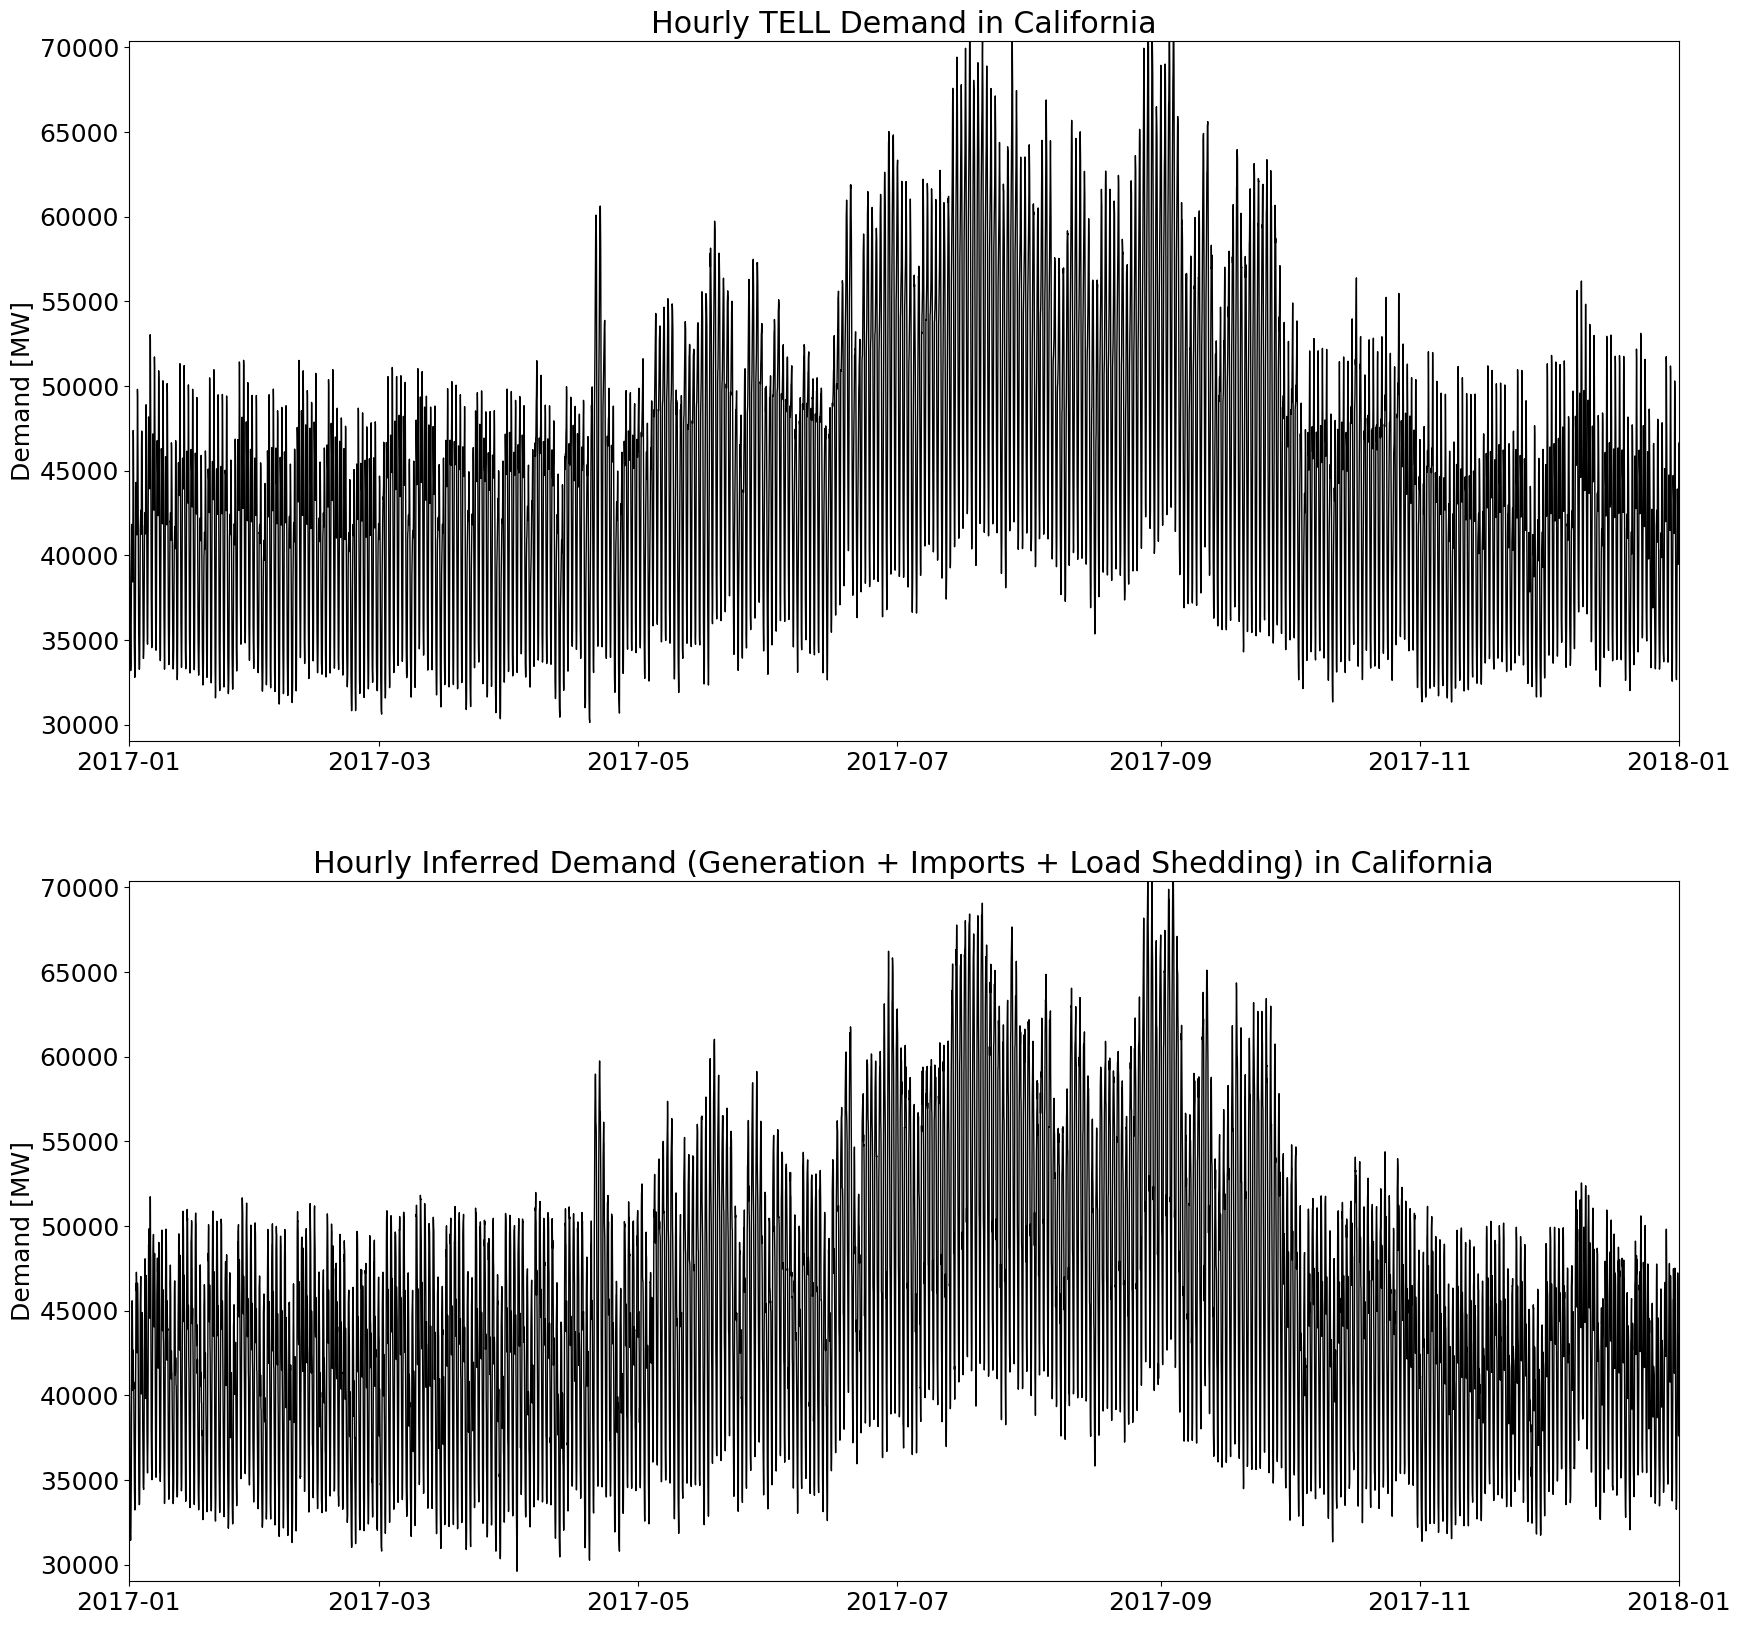

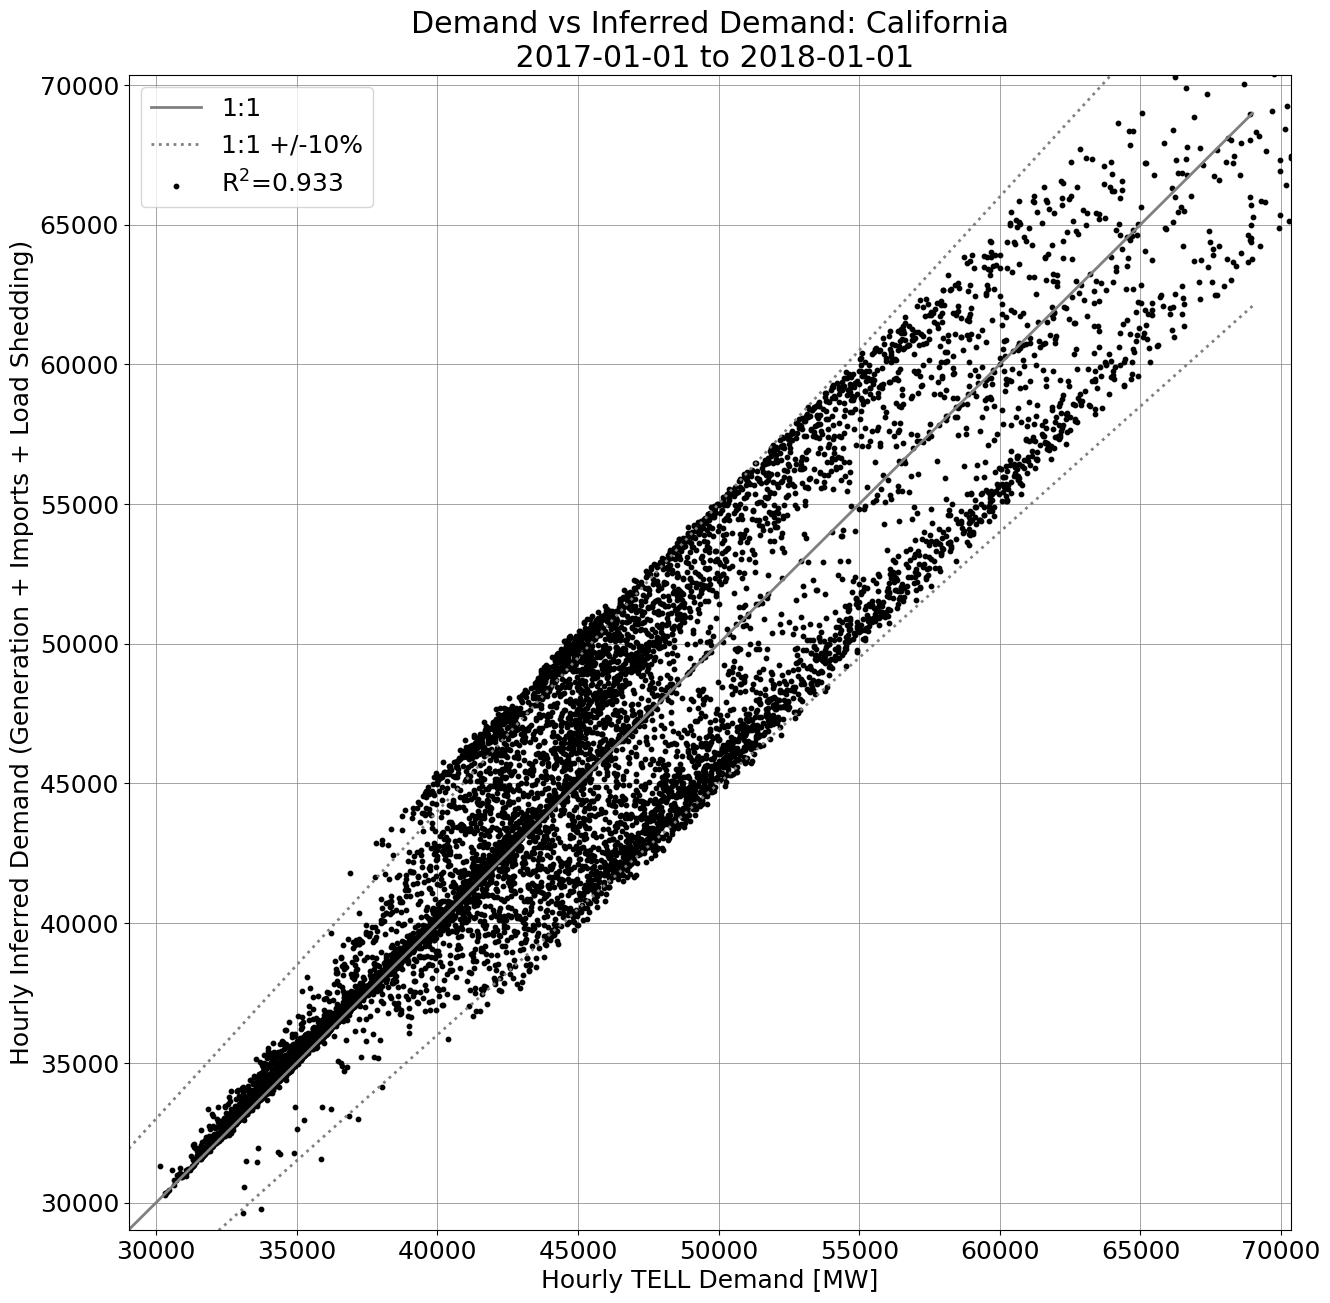

In [6]:
# Test the function:
output_df = plot_load_time_series(region = 'CA', 
                                  start_date = '2017-01-01', 
                                  end_date = '2018-01-01',
                                  metadata_input_dir = metadata_input_dir, 
                                  integrated_time_series_data_input_dir = integrated_time_series_data_input_dir, 
                                  image_output_dir = image_output_dir, 
                                  image_resolution = 150, 
                                  save_images = True)

output_df
